# **Crop Recommendation System**

## Domain Proyek

Pemilihan jenis tanaman yang sesuai dengan kondisi tanah dan lingkungan merupakan faktor penting dalam meningkatkan hasil pertanian. Kesalahan dalam menentukan jenis tanaman dapat menyebabkan produktivitas yang rendah.

Pada proyek ini dibangun model machine learning untuk merekomendasikan jenis tanaman berdasarkan beberapa parameter lingkungan seperti kandungan Nitrogen (N), Fosfor (P), Kalium (K), suhu, kelembapan, pH, dan curah hujan.

In [18]:
# Import Library

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [19]:
# Data Loading

df = pd.read_csv("../dataset_raw/Crop_recommendation.csv")

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [20]:
# Shape Dataset

print("Jumlah Baris dan Kolom:")
print(df.shape)

Jumlah Baris dan Kolom:
(2200, 8)


## Informasi Dataset

Dataset yang digunakan adalah Crop Recommendation Dataset.

Fitur:
- N (Nitrogen)
- P (Phosphorus)
- K (Potassium)
- temperature
- humidity
- ph
- rainfall

Target:
- label (jenis tanaman)

In [21]:
# Informasi Dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [22]:
# Missing Values

df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

### Kesimpulan Missing Value

Dataset tidak memiliki missing value sehingga tidak diperlukan proses imputasi data.

In [23]:
# Statistik Deskriptif

df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [24]:
# Jumlah Kelas

df['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

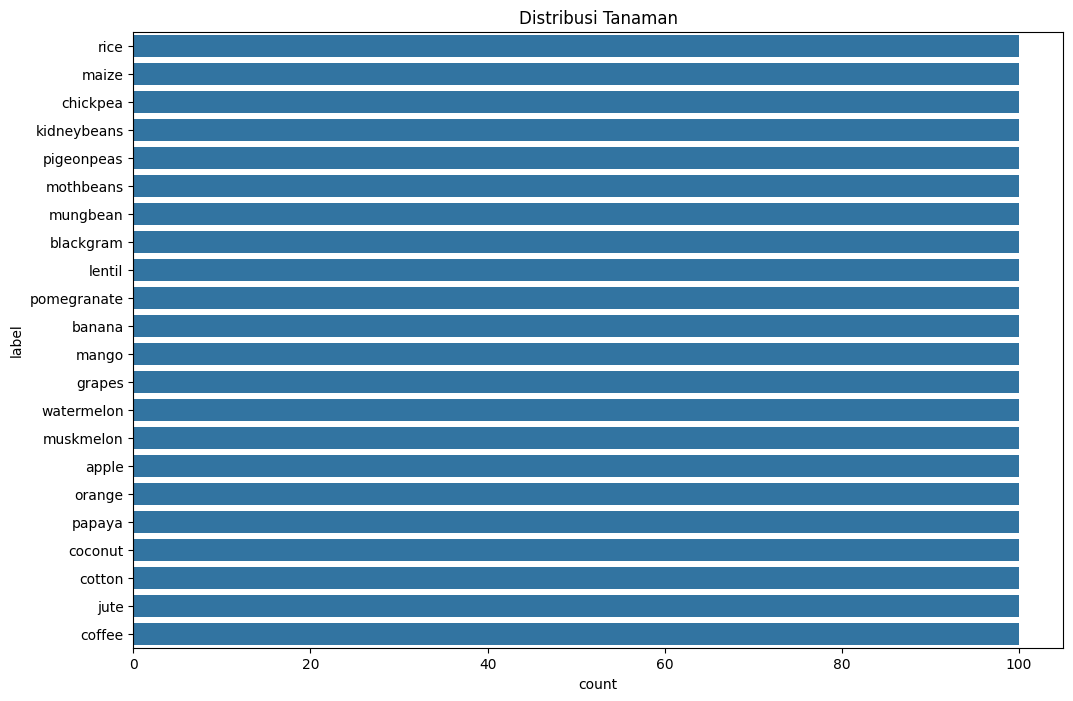

In [25]:
# Visualisasi Distribusi Label

plt.figure(figsize=(12,8))

sns.countplot(
    y=df['label'],
    order=df['label'].value_counts().index
)

plt.title("Distribusi Tanaman")

plt.show()

### Kesimpulan Distribusi Label

Setiap kelas tanaman memiliki jumlah data yang sama yaitu 100 sampel sehingga dataset tergolong seimbang.

# Exploratory Data Analysis (EDA)

EDA dilakukan untuk memahami karakteristik dataset sebelum dilakukan preprocessing dan pemodelan machine learning.

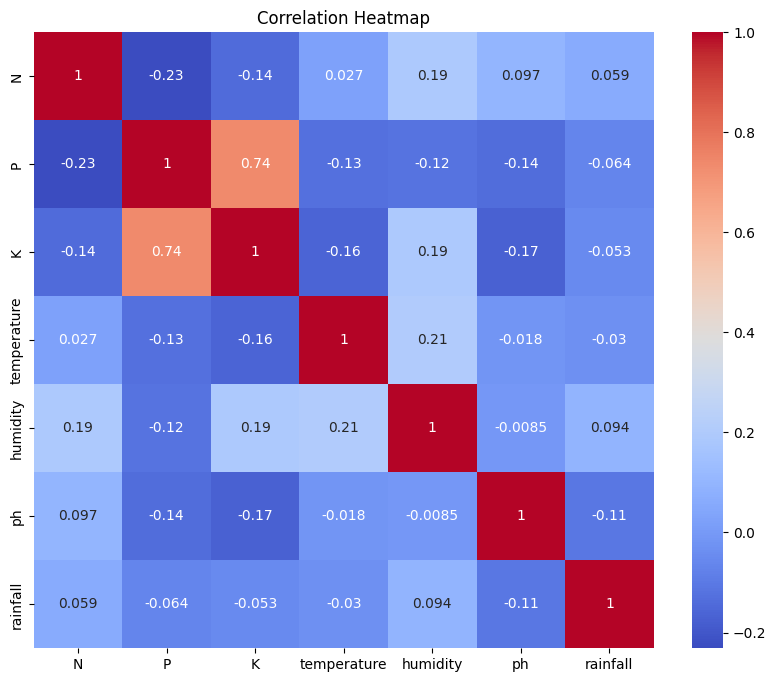

In [26]:
# Correlation Heatmap

plt.figure(figsize=(10,8))

sns.heatmap(
    df.drop('label', axis=1).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

### Kesimpulan Korelasi

Tidak terdapat korelasi yang sangat tinggi antar fitur sehingga seluruh fitur tetap digunakan dalam proses pemodelan.

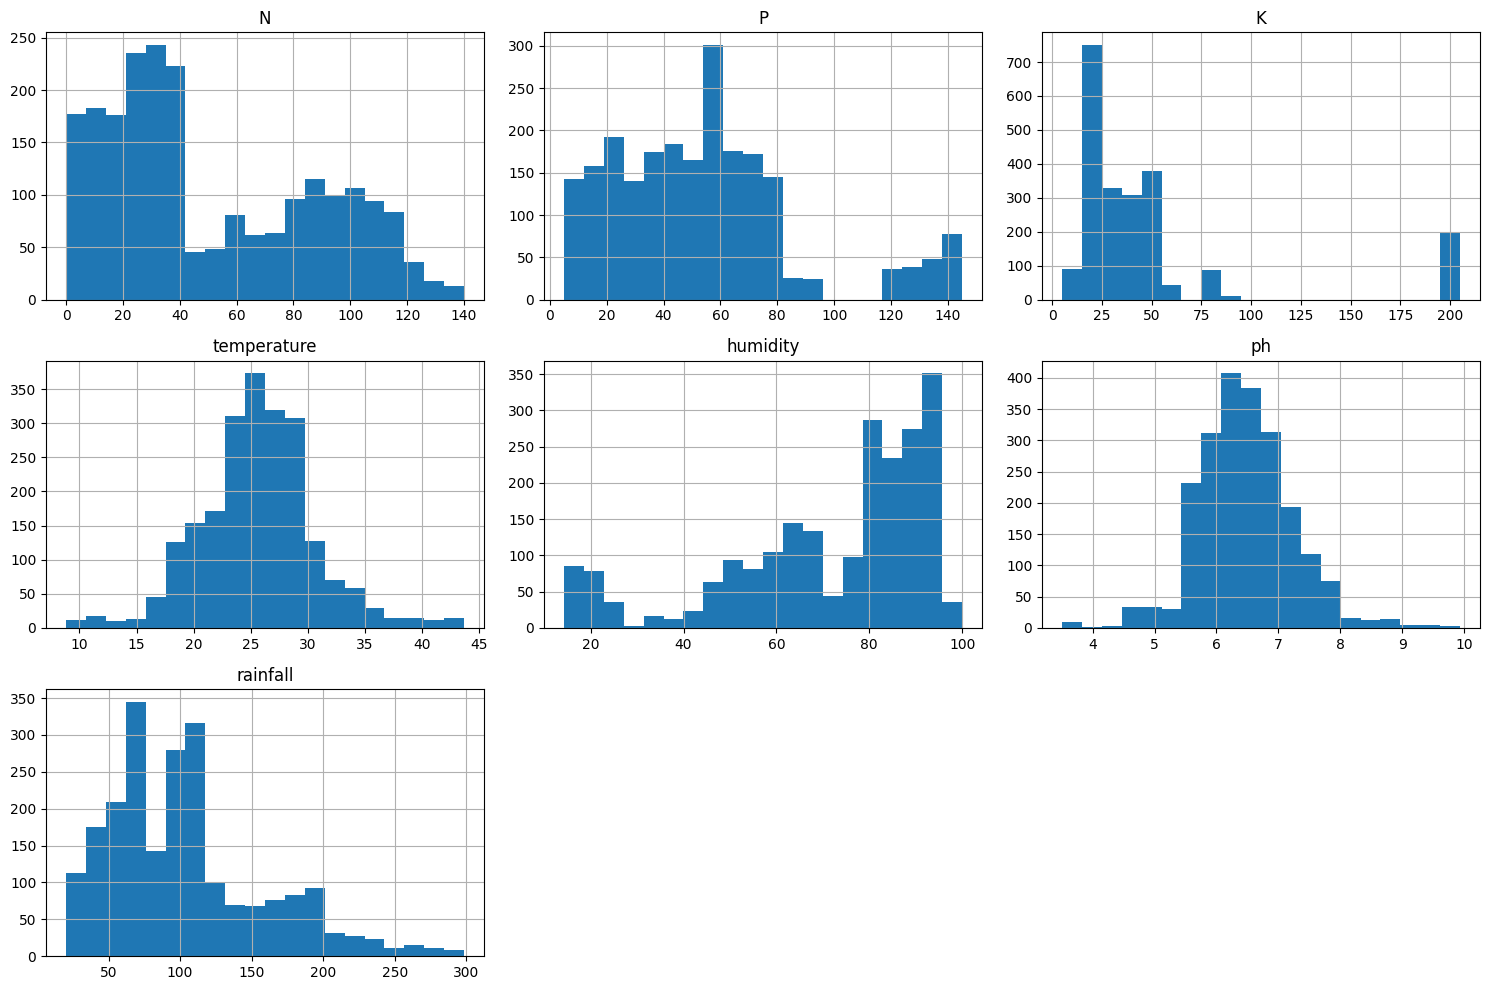

In [27]:
# Histogram Distribusi Fitur

df.drop(columns=['label']).hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

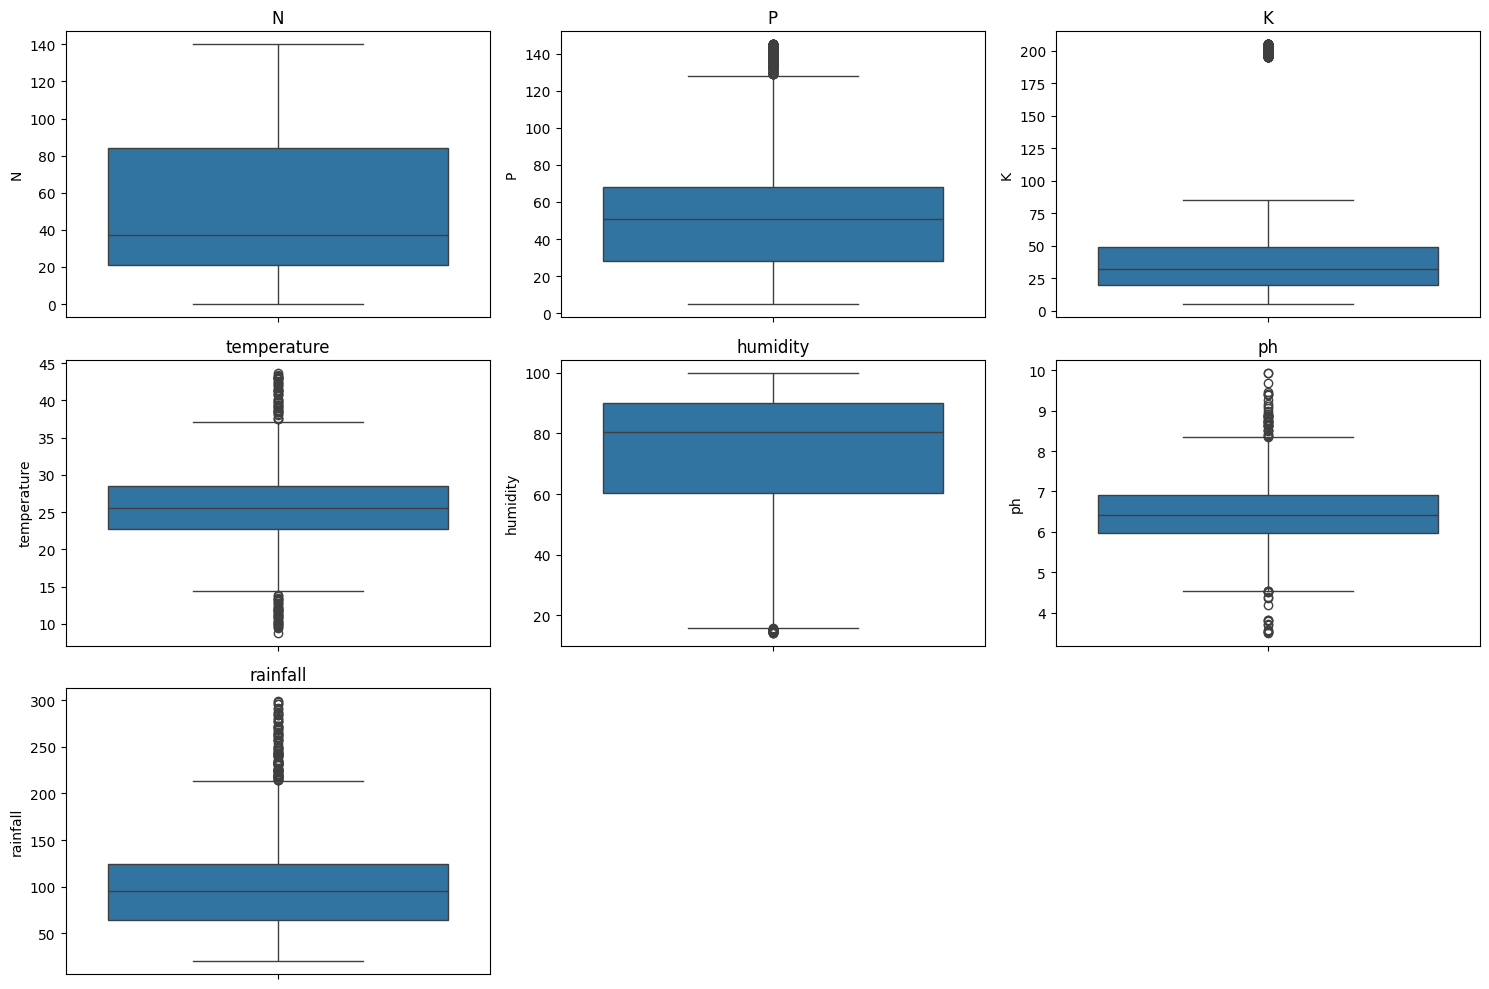

In [28]:
# Boxplot Outlier

plt.figure(figsize=(15,10))

for i, col in enumerate(
    df.drop(columns=['label']).columns
):

    plt.subplot(3,3,i+1)

    sns.boxplot(
        y=df[col]
    )

    plt.title(col)

plt.tight_layout()
plt.show()

## Kesimpulan EDA

Berdasarkan hasil eksplorasi data:

- Dataset terdiri dari 2200 data dan 8 fitur.
- Tidak ditemukan missing values.
- Distribusi kelas seimbang dengan masing-masing kelas memiliki 100 sampel.
- Tidak terdapat korelasi yang sangat tinggi antar fitur sehingga seluruh fitur tetap digunakan.
- Beberapa fitur memiliki outlier, namun masih berada pada rentang yang masuk akal sehingga tidak dilakukan penghapusan data.

Dataset dinilai siap untuk memasuki tahap preprocessing dan pembangunan model machine learning.

# Data Preprocessing

Tahap preprocessing dilakukan untuk mempersiapkan data sebelum digunakan pada proses pelatihan model machine learning.

## Pemeriksaan Data Duplikat

Pemeriksaan dilakukan untuk memastikan tidak terdapat data yang tercatat lebih dari satu kali.

In [29]:
# Jumlah Data Duplikat

print("Jumlah Data Duplikat:")
print(df.duplicated().sum())

Jumlah Data Duplikat:
0


## Encoding Label

Kolom label berupa data kategorikal sehingga perlu diubah menjadi numerik menggunakan LabelEncoder.

In [30]:
# Encode Label

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['label'] = encoder.fit_transform(
    df['label']
)

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,20


## Feature Scaling

Feature scaling dilakukan agar seluruh fitur berada pada skala yang sebanding dan dapat meningkatkan performa model machine learning.

In [31]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    df.drop(columns=['label'])
)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=df.drop(columns=['label']).columns
)

X_scaled.head()

,N,P,K,temperature,humidity,ph,rainfall
0,1.068797,-0.344551,-0.101688,-0.935587,0.472666,0.043302,1.810361
1,0.933329,0.140616,-0.141185,-0.759646,0.397051,0.734873,2.242058
2,0.255986,0.049647,-0.081939,-0.515898,0.486954,1.771510,2.921066
3,0.635298,-0.556811,-0.160933,0.172807,0.389805,0.660308,2.537048
4,0.743673,-0.344551,-0.121436,-1.083647,0.454792,1.497868,2.898373


## Pemisahan Feature dan Target

Dataset dipisahkan menjadi fitur (X) dan target (y) untuk kebutuhan pelatihan model machine learning.

In [32]:
# Pemisahan Feature dan Target

X = X_scaled
y = df['label']

print(X.shape)
print(y.shape)

(2200, 7)
(2200,)


## Menyimpan Dataset Hasil Preprocessing

Dataset hasil preprocessing disimpan untuk digunakan pada tahap pembangunan model.

In [33]:
# Simpan Dataset Hasil Preprocessing

dataset_final = X.copy()
dataset_final['label'] = y

dataset_final.to_csv(
    "dataset_preprocessing.csv",
    index=False
)

print("Dataset berhasil disimpan")

Dataset berhasil disimpan


## Kesimpulan Preprocessing

Tahapan preprocessing yang dilakukan meliputi:

- Pemeriksaan data duplikat.
- Encoding label menggunakan LabelEncoder.
- Standardisasi fitur menggunakan StandardScaler.
- Pemisahan fitur dan target.

Dataset hasil preprocessing telah siap digunakan pada tahap pembangunan model machine learning.